# Working with PUNCH data

This notebook provides a guide on how to query PUNCH data from the SDAC / VSO using Python tools, and how to load and display this data. Note that PUNCH provides some bespoke tools to assist Fido in querying the complex range of data products and versions of PUNCH.

If this is the first time running this notebook in colab, you'll need to install punchbowl.

In [ ]:
%%capture
!pip install punchbowl

First we can load some libraries. Note that importing punchbowl directly is needed to register the bespoke PUNCH fido tools.

In [ ]:
from sunpy.net import Fido
from sunpy.net import attrs as a

import punchbowl
from punchbowl.data import punch_io, visualize

from google.colab import output
output.enable_custom_widget_manager()

With a range of dates and a PUNCH data product in mind, we can begin querying data. Here we’ll search for level 3 clear low-noise mosaics from 1-2 November 2025. We’re looking for CAM data, so a product code of “CA” and a instrument code of “M”. We can construct a query using the Fido tool, specifying search attributes:

In [ ]:
result_cam = Fido.search(a.Time('2025/09/22 00:00:00', '2025/09/22 12:00:00'),
                     a.punch.ProductCode.ca, # (ca for clear low-noise), or pa for polarized low-noise, etc.
                     a.Instrument.m, # (m for mosaic), or a.Instrument.nfi_4, etc for earlier levels.
                     a.Level.three,
                     a.punch.DataVersion.newest, # or a.punch.DataVersion.zero_j, etc.
                     a.punch.FileType.fits) # or a.punch.FileType.jp2

indices = [i for i, r in enumerate(result_cam[0]) if "0k" in str(r["DataVersion"])]
result_cam = result_cam[0][indices]

result_cam

Start Time,End Time,Level,ProductCode,Instrument,DataVersion,Source,Provider,FileType
Time,Time,str1,str2,str1,str2,str5,str4,str4
2025-09-22 00:48:00.000,2025-09-22 00:48:00.999,3,CA,M,0k,PUNCH,SwRI,fits
2025-09-22 01:20:00.000,2025-09-22 01:20:00.999,3,CA,M,0k,PUNCH,SwRI,fits
2025-09-22 01:52:00.000,2025-09-22 01:52:00.999,3,CA,M,0k,PUNCH,SwRI,fits
2025-09-22 02:24:00.000,2025-09-22 02:24:00.999,3,CA,M,0k,PUNCH,SwRI,fits
2025-09-22 02:56:00.000,2025-09-22 02:56:00.999,3,CA,M,0k,PUNCH,SwRI,fits
2025-09-22 03:28:00.000,2025-09-22 03:28:00.999,3,CA,M,0k,PUNCH,SwRI,fits
2025-09-22 04:00:00.000,2025-09-22 04:00:00.999,3,CA,M,0k,PUNCH,SwRI,fits
2025-09-22 04:32:00.000,2025-09-22 04:32:00.999,3,CA,M,0k,PUNCH,SwRI,fits
2025-09-22 05:04:00.000,2025-09-22 05:04:00.999,3,CA,M,0k,PUNCH,SwRI,fits


This results in a table of available data products that match the search criteria. Let's change our query now to polarized low-noise mosaics over the same time range.

In [ ]:
result_pam = Fido.search(a.Time('2025/09/22 00:00:00', '2025/09/22 12:00:00'),
                     a.punch.ProductCode.pa, # (ca for clear low-noise), or pa for polarized low-noise, etc.
                     a.Instrument.m, # (m for mosaic), or a.Instrument.nfi_4, etc for earlier levels.
                     a.Level.three,
                     a.punch.DataVersion.newest, # or a.punch.DataVersion.zero_j, etc.
                     a.punch.FileType.fits) # or a.punch.FileType.jp2

result_pam

Start Time,End Time,Level,ProductCode,Instrument,DataVersion,Source,Provider,FileType
Time,Time,str1,str2,str1,str2,str5,str4,str4
2025-09-22 00:16:00.000,2025-09-22 00:16:00.999,3,PA,M,0j,PUNCH,SwRI,fits
2025-09-22 00:48:00.000,2025-09-22 00:48:00.999,3,PA,M,0j,PUNCH,SwRI,fits
2025-09-22 01:20:00.000,2025-09-22 01:20:00.999,3,PA,M,0j,PUNCH,SwRI,fits
2025-09-22 01:52:00.000,2025-09-22 01:52:00.999,3,PA,M,0j,PUNCH,SwRI,fits
2025-09-22 02:24:00.000,2025-09-22 02:24:00.999,3,PA,M,0j,PUNCH,SwRI,fits
2025-09-22 02:56:00.000,2025-09-22 02:56:00.999,3,PA,M,0j,PUNCH,SwRI,fits
2025-09-22 03:28:00.000,2025-09-22 03:28:00.999,3,PA,M,0j,PUNCH,SwRI,fits
2025-09-22 04:00:00.000,2025-09-22 04:00:00.999,3,PA,M,0j,PUNCH,SwRI,fits
2025-09-22 04:32:00.000,2025-09-22 04:32:00.999,3,PA,M,0j,PUNCH,SwRI,fits


Now let's download some files to work with.

In [ ]:
files = Fido.fetch(result_cam)

Files Downloaded:   0%|          | 0/22 [00:00<?, ?file/s]

PUNCH_L3_CAM_20250922022400_v0k.fits:   0%|          | 0.00/25.4M [00:00<?, ?B/s]

PUNCH_L3_CAM_20250922012000_v0k.fits:   0%|          | 0.00/25.3M [00:00<?, ?B/s]

PUNCH_L3_CAM_20250922025600_v0k.fits:   0%|          | 0.00/25.0M [00:00<?, ?B/s]

PUNCH_L3_CAM_20250922015200_v0k.fits:   0%|          | 0.00/25.3M [00:00<?, ?B/s]

...

PUNCH_L3_CAM_20250922095200_v0k.fits:   0%|          | 0.00/25.3M [00:00<?, ?B/s]

PUNCH_L3_CAM_20250922102400_v0k.fits:   0%|          | 0.00/25.3M [00:00<?, ?B/s]

PUNCH_L3_CAM_20250922105600_v0k.fits:   0%|          | 0.00/25.5M [00:00<?, ?B/s]

PUNCH_L3_CAM_20250922112800_v0k.fits:   0%|          | 0.00/25.2M [00:00<?, ?B/s]

PUNCH_L3_CAM_20250922120000_v0k.fits:   0%|          | 0.00/25.2M [00:00<?, ?B/s]

The variables *files* will now reference the paths to the files we just downloaded.

We can plot the first image as a test. Let's start with the basics.

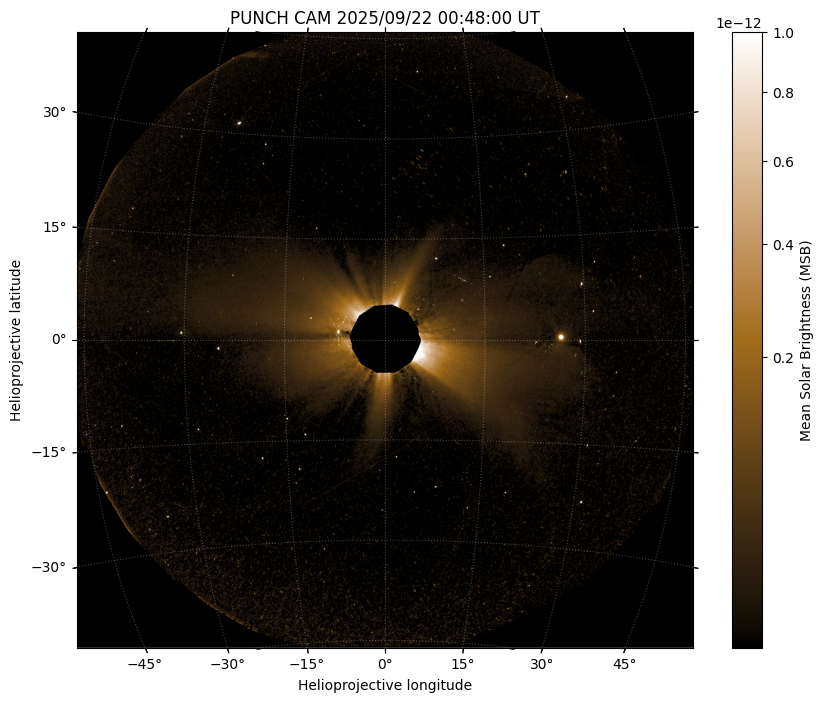

In [ ]:
fig, ax = visualize.plot_punch(files[0])

This is the default behavior of the punchbowl *plot_punch* function. It does contain quite a few features that allow for plotting customization.

Let's say we're making a plot for a presentation, and we don't need the colorbar or plotting axes.

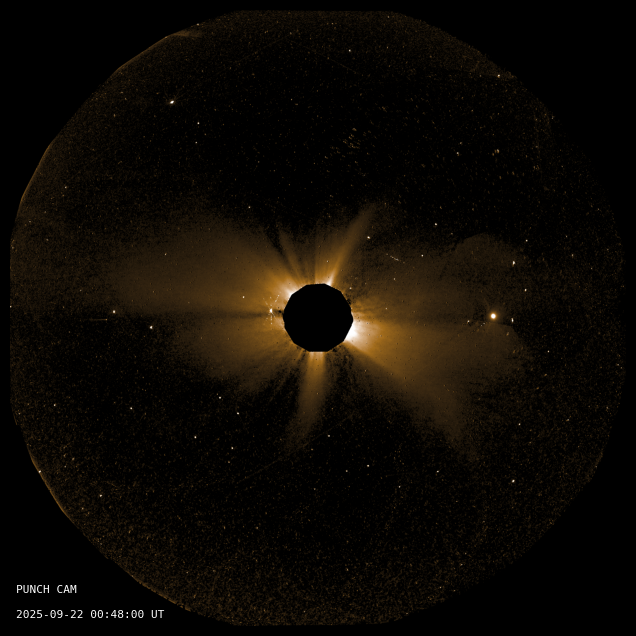

In [ ]:
fig, ax = visualize.plot_punch(files[0], axes_off=True)

For a more complex example let’s bring down the vmax value a bit, alter the gamma value, relabel the axes, and relabel the plot title.

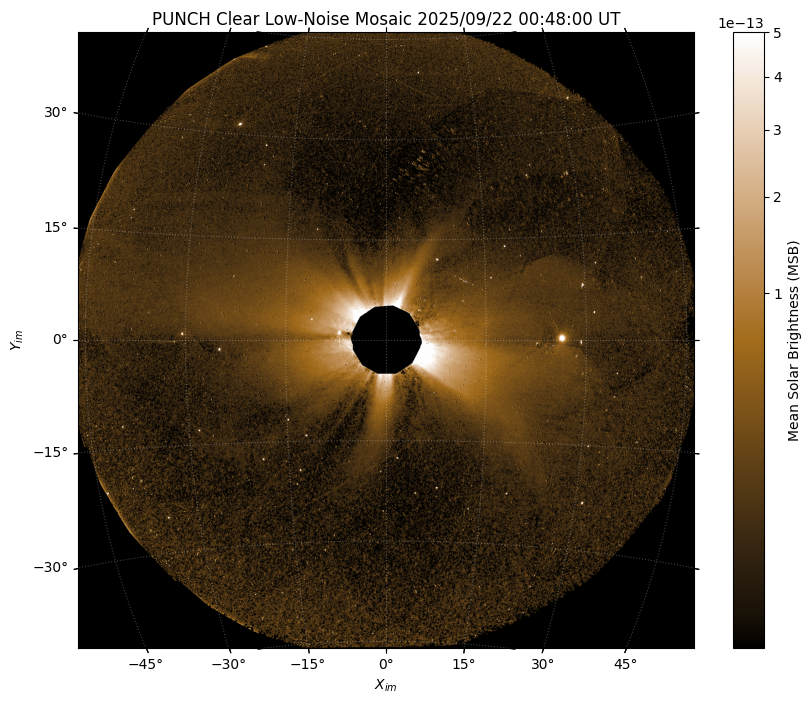

In [ ]:
fig, ax = visualize.plot_punch(files[0], vmin=5e-15, vmax=5e-13, gamma=1/3, axes_labels=(r'$X_{im}$', r'$Y_{im}$'), title_prefix="PUNCH Clear Low-Noise Mosaic")

From here you can customize plots to your heart's content. The full set of options are available in the plot_punch function's documentation. Note that not all plotting options are interoperable.

Now that we've figured out plotting options, let's make an animation using one of these examples. Let's focus on the barebones plot to make an animation for a presentation, say.

In [ ]:
visualize.animate_punch(files, output_path="PUNCH_CAM.mp4", axes_off=True, trim_edge=(0.081, 0.705))

  0%|          | 0/22 [00:00<?, ?it/s]

From here you can download the generated animation in the file browser to the left in colab. Note that the individual plotting options can be passed through the animator as well.

Now try editing this notebook to focus on a different time span, or to change any of the plotting parameters.